In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41987")
client

<Client: 'tcp://127.0.0.1:41987' processes=9 threads=72, memory=136.41 GiB>

In [2]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [5]:
NXX = 50
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/salt.fesom.2090.nc"
                              % NXX),
                     chunks={"nz1":4,"x":10000}
                    ).rename_dims({'x':'nod2'})
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2090.nc"
                             % NXX),
                     chunks={"nz":4,"x":10000}
                    ).rename_dims({'x':'nod2'})
ds1, ds

(<xarray.Dataset> Size: 29GB
 Dimensions:  (time: 12, nz1: 47, nod2: 12952215)
 Coordinates:
   * time     (time) datetime64[ns] 96B 2090-01-31T23:57:00 ... 2090-12-31T23:...
   * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: nod2
 Data variables:
     salt     (time, nz1, nod2) float32 29GB dask.array<chunksize=(1, 4, 10000), meta=np.ndarray>
 Attributes: (12/21)
     CDI:                                 Climate Data Interface version 2.2.4...
     Conventions:                         CF-1.6
     FESOM_model:                         FESOM2
     FESOM_website:                       fesom.de
     FESOM_git_SHA:                       e23bc823
     FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
     ...                                  ...
     FESOM_evp_rheol_steps:               120
     FESOM_opt_visc:                      7
     FESOM_use_wsplit:                    -1
     FESOM_autorotate_back_

In [6]:
iz2000 = 31
iz4300 = 40
dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 ).isel(nz1=slice(None,iz4300))
dz

<xarray.DataArray (nz1: 40)> Size: 320B
array([  5.,   5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        15.,  20.,  25.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 170., 200., 220., 230., 250., 250.,
       250., 250., 250., 250., 250., 250., 250.])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03

In [7]:
nz = 47

plt_contb = True        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tcf'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, -30] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
# proj = 'rob'               # Robinson projection
proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 2                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 2                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cmin      = None
cmax      = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6

cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     ) 

In [9]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )
mesh

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________

In [10]:
diag = xr.open_dataset(op.join(mesh_path, 'fesom.mesh.diag.nc'),
                       chunks={'nz':1,"nz1":1,'elem_n':100000,
                               'nod_n':100000,'edg_n':100000}
                      )
area = xr.DataArray(.5*(diag.nod_area.isel(nz=slice(None,-1)).data
                        + diag.nod_area.isel(nz=slice(1,None)).data
                       ),
                    dims=ds1.salt.isel(time=0).dims, 
                    coords=ds1.salt.isel(time=0).coords
                   ).chunk(ds1.salt.isel(time=0).chunks
                          ).isel(nz1=slice(None,iz4300))
depth = diag.zbar_n_bottom
depth.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
area.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
diag

<xarray.Dataset> Size: 10GB
Dimensions:            (nz: 48, nz1: 47, elem: 25742475, nod2: 12952215, n3: 3,
                        n2: 2, N: 8, edg_n: 38695599, n4: 4)
Coordinates:
  * nz                 (nz) float64 384B 0.0 -5.0 -10.0 ... -6e+03 -6.25e+03
  * nz1                (nz1) float64 376B -2.5 -7.5 ... -5.825e+03 -6.125e+03
Dimensions without coordinates: elem, nod2, n3, n2, N, edg_n, n4
Data variables: (12/19)
    elem_area          (elem) float64 206MB dask.array<chunksize=(25742475,), meta=np.ndarray>
    nlevels_nod2D      (nod2) int32 52MB dask.array<chunksize=(12952215,), meta=np.ndarray>
    nlevels            (elem) int32 103MB dask.array<chunksize=(25742475,), meta=np.ndarray>
    nod_in_elem2D_num  (nod2) int32 52MB dask.array<chunksize=(12952215,), meta=np.ndarray>
    nod_part           (nod2) int32 52MB dask.array<chunksize=(12952215,), meta=np.ndarray>
    elem_part          (elem) int32 103MB dask.array<chunksize=(25742475,), meta=np.ndarray>
    ...                 ...
    nod_in_elem2D      (N, nod2) int32 414MB dask.array<chunksize=(8, 12952215), meta=np.ndarray>
    edges              (n2, edg_n) int32 310MB dask.array<chunksize=(2, 100000), meta=np.ndarray>
    edge_tri           (n2, edg_n) int32 310MB dask.array<chunksize=(2, 100000), meta=np.ndarray>
    edge_cross_dxdy    (n4, edg_n) float64 1GB dask.array<chunksize=(4, 100000), meta=np.ndarray>
    gradient_sca_x     (elem, n3) float64 618MB dask.array<chunksize=(25742475, 3), meta=np.ndarray>
    gradient_sca_y     (elem, n3) float64 618MB dask.array<chunksize=(25742475, 3), meta=np.ndarray>

In [10]:
ystart = 2096
NXX = 50

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int)))

for yy in range(ystart,2101):
    
    p_path = op.join(ddir,'N%02d/outdata/fesom/ke_PFULL.fesom.%4d.nc'
                      % (NXX,yy))
    dw_path = op.join(ddir,'N%02d/outdata/fesom/ke_dW.fesom.%4d.nc'
                      % (NXX,yy))
    pdw_path = op.join(ddir,'N%02d/outdata/fesom/W_x_RHO.fesom.%4d.nc'
                      % (NXX,yy))
    # h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
    #                   % (NXX,yy))
        
    if yy == ystart:
        months = JFMJAS[2:]
        print(months)
    else:
        months = JFMJAS
    
    for mm in months:
        # mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
        #                           vname="MLD3", do_info=False,
        #                           year=yy, mon=[mm]
        #                          ).chunk({'nod2':100000})
        for i in range(iz4300):
            if i == 0:
                p = tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                          vname="ke_PFULL", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                         year=yy, mon=[mm]
                                         ).chunk({'nod2':100000})
                dw = tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                          vname="ke_dW", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                          year=yy, mon=[mm]
                                         ).chunk({'nod2':100000})
                pdw = tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                          vname="ke_wrho", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                           year=yy, mon=[mm]
                                         ).chunk({'nod2':100000})
            else:
                p = xr.concat([p, 
                              tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                                  vname="ke_PFULL", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=[mm]
                                     ).chunk({'nod2':100000})
                              ], "nz1")
                dw = xr.concat([dw, 
                              tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                                  vname="ke_dW", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=[mm]
                                     ).chunk({'nod2':100000})
                              ], "nz1")
                pdw = xr.concat([pdw, 
                              tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                                  vname="ke_wrho", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=[mm]
                                     ).chunk({'nod2':100000})
                              ], "nz1")

        ppdwp = (pdw.W_x_RHO / dt 
                 - (p.ke_PFULL * dw.ke_dW)
                )
        ppdwp.reset_coords(drop=True).to_dataset(name="WpRHOp"
                                                ).to_zarr(op.join(sdir,
                                            "fesom2/next/ppdwp/ppdwp_%4d-%02d.zarr" 
                               % (yy,mm)),
                       mode="w")
        ppdwp.close()
        p.close(), dw.close(), pdw.close()
        del ppdwp
        print("iiiiiiiiiiiiiiiiiiii")
        print("iiSaved to scratch!!")
        print("!!!!!!!!!!!!!!!!!!!!")
        print(mm)
    print(yy)

[3 7 8 9]


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

iiiiiiiiiiiiiiiiiiii
iiSaved to scratch!!
!!!!!!!!!!!!!!!!!!!!
3


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyvi

iiiiiiiiiiiiiiiiiiii
iiSaved to scratch!!
!!!!!!!!!!!!!!!!!!!!
7


...

iiiiiiiiiiiiiiiiiiii
iiSaved to scratch!!
!!!!!!!!!!!!!!!!!!!!
7


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyvi

iiiiiiiiiiiiiiiiiiii
iiSaved to scratch!!
!!!!!!!!!!!!!!!!!!!!
8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyvi

iiiiiiiiiiiiiiiiiiii
iiSaved to scratch!!
!!!!!!!!!!!!!!!!!!!!
9
2100


[1 2 3 7 8 9]


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce5353f20>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


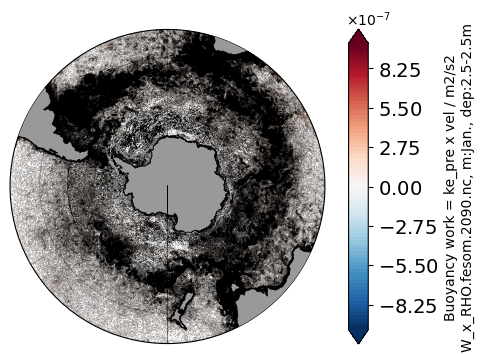

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce73635c0>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


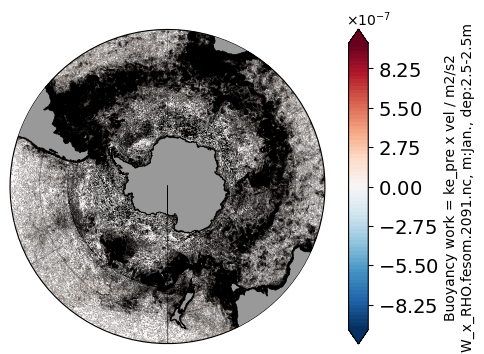

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce9076030>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


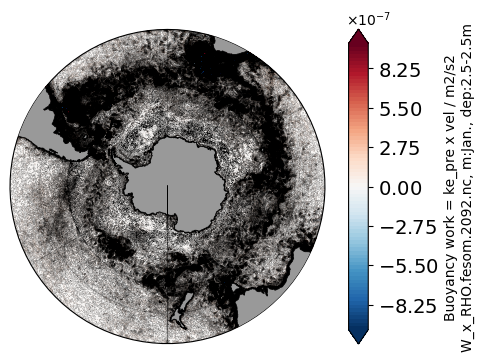

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce8185520>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


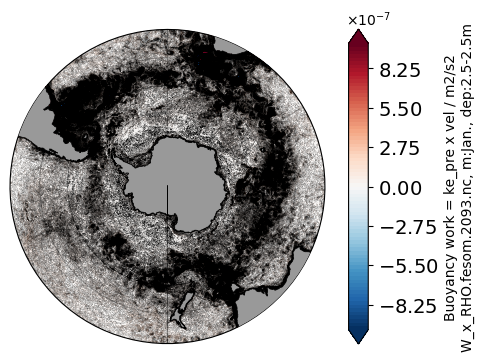

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffcca0877d0>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


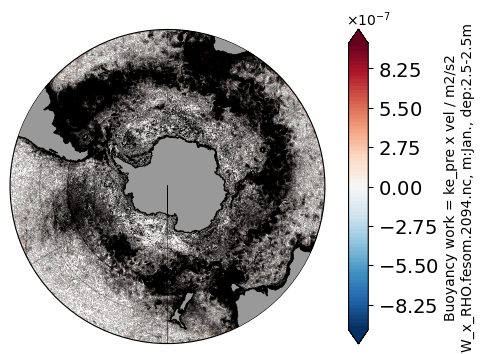

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffcca57a1b0>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


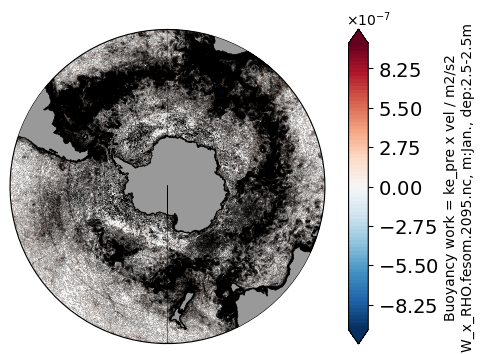

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce4b64830>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


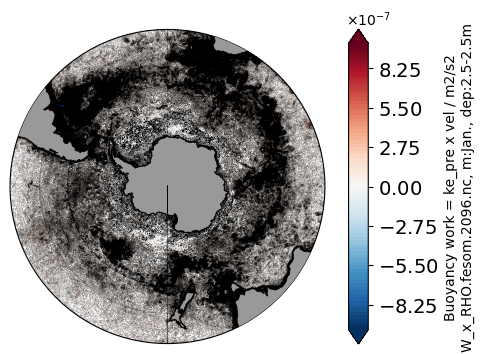

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce3c96960>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


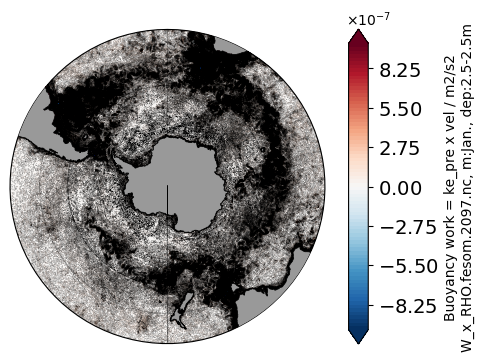

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffcca0af7d0>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


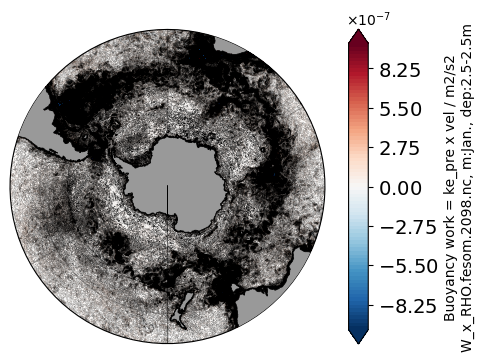

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffd0cd7e270>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


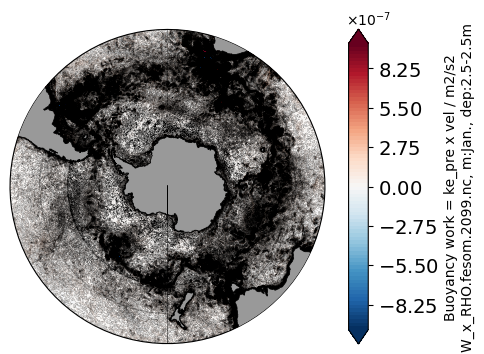

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffce8859f70>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


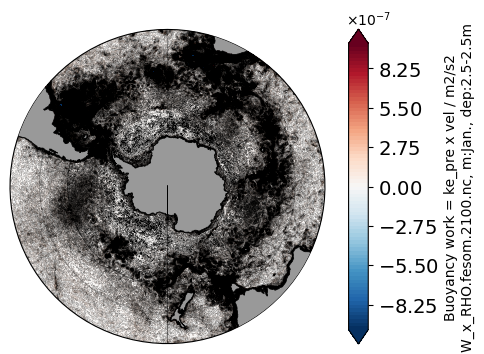

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

...

7


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/ap

9
2100


In [13]:
ystart = 2090
NXX = 50

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int)))

for yy in range(ystart,2101):
    
    # p_path = op.join(ddir,'N%02d/outdata/fesom/ke_PFULL.fesom.%4d.nc'
    #                   % (NXX,yy))
    # dw_path = op.join(ddir,'N%02d/outdata/fesom/ke_dW.fesom.%4d.nc'
    #                   % (NXX,yy))
    # pdw_path = op.join(ddir,'N%02d/outdata/fesom/W_x_RHO.fesom.%4d.nc'
    #                   % (NXX,yy))
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                      % (NXX,yy))
        
    if yy == ystart:
        months = JFMJAS[:]
        print(months)
    else:
        months = JFMJAS
    
    for mm in months:
        mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                  vname="MLD3", do_info=False,
                                  year=yy, mon=[mm]
                                 ).chunk({'nod2':100000})
        # for i in range(iz4300):
        #     if i == 0:
        #         p = tpv.load_data_fesom2(mesh, p_path, do_filename=True,
        #                                   vname="ke_PFULL", do_info=False,
        #                                   depth=[ds1.nz1[i].values], 
        #                                  year=yy, mon=[mm]
        #                                  ).chunk({'nod2':100000})
        #         dw = tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
        #                                   vname="ke_dW", do_info=False,
        #                                   depth=[ds1.nz1[i].values], 
        #                                   year=yy, mon=[mm]
        #                                  ).chunk({'nod2':100000})
        #         pdw = tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
        #                                   vname="ke_wrho", do_info=False,
        #                                   depth=[ds1.nz1[i].values], 
        #                                    year=yy, mon=[mm]
        #                                  ).chunk({'nod2':100000})
        #     else:
        #         p = xr.concat([p, 
        #                       tpv.load_data_fesom2(mesh, p_path, do_filename=True,
        #                                           vname="ke_PFULL", do_info=False,
        #                                           depth=[ds1.nz1[i].values], 
        #                                            year=yy, mon=[mm]
        #                              ).chunk({'nod2':100000})
        #                       ], "nz1")
        #         dw = xr.concat([dw, 
        #                       tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
        #                                           vname="ke_dW", do_info=False,
        #                                           depth=[ds1.nz1[i].values], 
        #                                            year=yy, mon=[mm]
        #                              ).chunk({'nod2':100000})
        #                       ], "nz1")
        #         pdw = xr.concat([pdw, 
        #                       tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
        #                                           vname="ke_wrho", do_info=False,
        #                                           depth=[ds1.nz1[i].values], 
        #                                            year=yy, mon=[mm]
        #                              ).chunk({'nod2':100000})
        #                       ], "nz1")
        
        dspw = xr.open_zarr(op.join(sdir,
                                    "fesom2/next/ppdwp/ppdwp_%4d-%02d.zarr" 
                                    % (yy,mm))
                           )

        # ppdwp = (pdw.W_x_RHO / dt 
        #          - (p.ke_PFULL * dw.ke_dW)
        #         )

        ppdwpH = ((dspw.WpRHOp
                   * dz
                  ).where(dspw.WpRHOp.nz1<np.abs(mld.MLD3)
                         ).sum("nz1",skipna=True) 
                  / np.abs(mld.MLD3)
                 ).reset_coords(drop=True).to_dataset(name="WpRHOpH")
        if mm == 1:
            print(ppdwpH)
            hfig, hax, hcb = tpv.plot_hslice(
                mesh, 
                data=ppdwpH.load(), 
                cinfo=cinfo, 
                box=box, nrow=1, ncol=1, 
                proj=proj, do_rescale=do_rescale,  
                do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
                plt_contr=plt_contr, plt_contl=plt_contl, 
                do_enum=do_enum, 
                axl_opt=dict({'fontsize':10, 'pad': 15}),
                ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                             'cb_plt_single':True, 'cb_pos':'vertical'}),
                cbl_opt=dict({'fontsize':10}), cb_label=None, 
                cbtl_opt=dict(),
                # do_save=save_path, 
                # save_dpi=save_dpi
            ) 
            plt.show()
        ppdwpH.to_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                               % (NXX,yy,mm)),
                       mode="w")
        ppdwpH.close()
        dspw.close(), mld.close()
        print(mm)
    print(yy)

In [8]:
incre = 0.
regions = dict(GulfStrEx = {"we":-70-incre, "ea":-55+incre, "so":32-incre, "no":42+incre},
               KuroEx    = {"we":142-incre, "ea":157+incre, "so":32-incre, "no":42+incre},
               DrakePass = {"we":-65-incre, "ea":-45+incre, "so":-70-incre,"no":-55+incre},
               Agulhas   = {"we":10-incre, "ea":25+incre, "so":-45-incre, "no":-35+incre},
               WestPac   = {"we":130-incre, "ea":145+incre, "so":10-incre, "no":25+incre},
               EqAtl     = {"we":-30-incre, "ea":-15+incre, "so":-10-incre, "no":10+incre},
               EastPac   = {"we":-145-incre, "ea":-130+incre, "so":35-incre, "no":50+incre}
              )

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

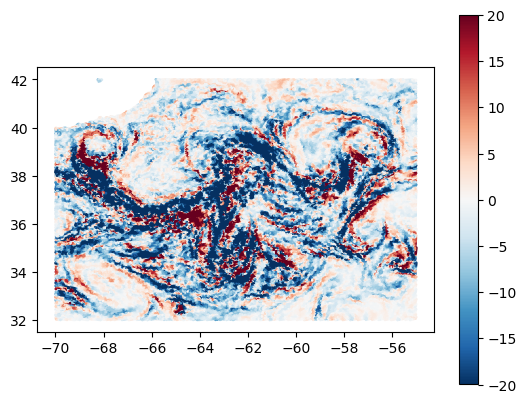

<xarray.DataArray (nz1: 40)> Size: 320B
dask.array<truediv, shape=(40,), dtype=float64, chunksize=(4,), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    Mixed Layer Depth
    units:        m
    description:  Mixed Layer Depth
    datapath:     /work/uo0119/a270067/runtime/awicm3-v3.1/N50/outdata/fesom/...
    runid:        fesom
    do_file:      run
    ...           ...
    str_ldep:     
    str_lsave:    MLD2.fesom.2091.nc_mJan.
    is_data:      scalar
    is_ie2n:      False
    do_compute:   False
    descript:      <xarray.DataArray 'mul-c05b270ae232b24bb2ad29b856b7aaa9' (nz1: 40, nod2: 65150)> Size: 21MB
dask.array<where, shape=(40, 65150), dtype=float64, chunksize=(4, 9991), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
  * nod2     (nod2) int64 521kB 6218361 6218370 6218371 ... 6508615 6508616 <xarra

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

3


...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

9


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 377.43 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 381.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask direc

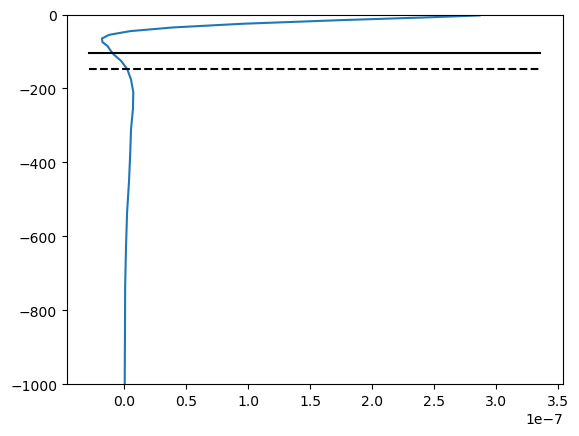

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 386.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-pr

2091


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

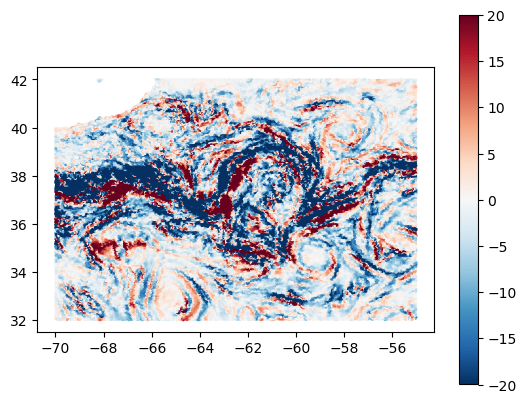

<xarray.DataArray (nz1: 40)> Size: 320B
dask.array<truediv, shape=(40,), dtype=float64, chunksize=(4,), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    Mixed Layer Depth
    units:        m
    description:  Mixed Layer Depth
    datapath:     /work/uo0119/a270067/runtime/awicm3-v3.1/N50/outdata/fesom/...
    runid:        fesom
    do_file:      run
    ...           ...
    str_ldep:     
    str_lsave:    MLD2.fesom.2092.nc_mJan.
    is_data:      scalar
    is_ie2n:      False
    do_compute:   False
    descript:      <xarray.DataArray 'mul-c05b270ae232b24bb2ad29b856b7aaa9' (nz1: 40, nod2: 65150)> Size: 21MB
dask.array<where, shape=(40, 65150), dtype=float64, chunksize=(4, 9991), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
  * nod2     (nod2) int64 521kB 6218361 6218370 6218371 ... 6508615 6508616 <xarra

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

3


...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

9


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 377.43 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 381.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask direc

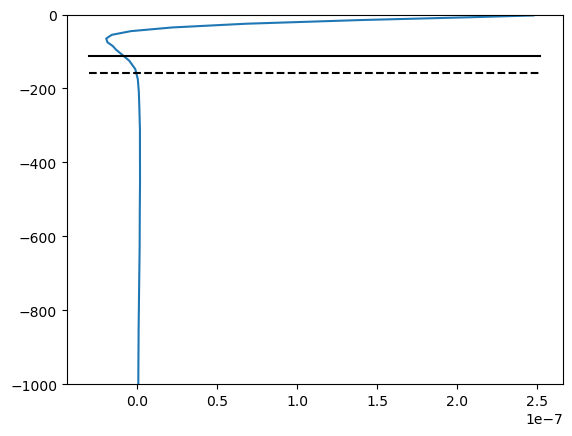

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 386.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-pr

2092


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

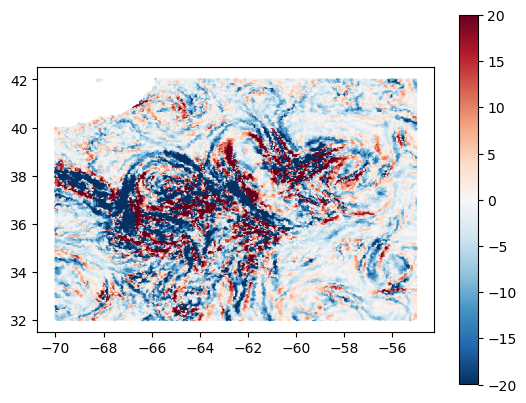

<xarray.DataArray (nz1: 40)> Size: 320B
dask.array<truediv, shape=(40,), dtype=float64, chunksize=(4,), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    Mixed Layer Depth
    units:        m
    description:  Mixed Layer Depth
    datapath:     /work/uo0119/a270067/runtime/awicm3-v3.1/N50/outdata/fesom/...
    runid:        fesom
    do_file:      run
    ...           ...
    str_ldep:     
    str_lsave:    MLD2.fesom.2093.nc_mJan.
    is_data:      scalar
    is_ie2n:      False
    do_compute:   False
    descript:      <xarray.DataArray 'mul-c05b270ae232b24bb2ad29b856b7aaa9' (nz1: 40, nod2: 65150)> Size: 21MB
dask.array<where, shape=(40, 65150), dtype=float64, chunksize=(4, 9991), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
  * nod2     (nod2) int64 521kB 6218361 6218370 6218371 ... 6508615 6508616 <xarra

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

3


...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

9


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 377.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 381.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask direc

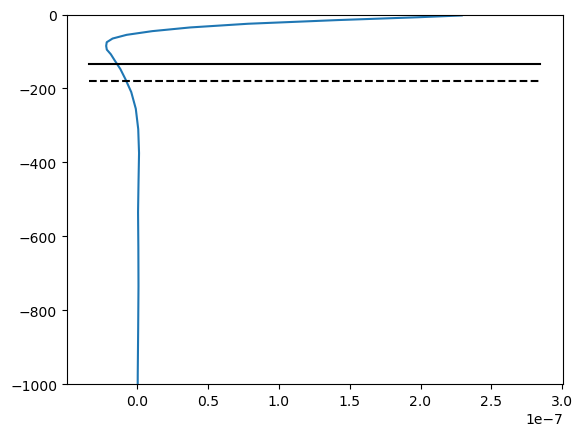

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 386.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-pr

2093


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

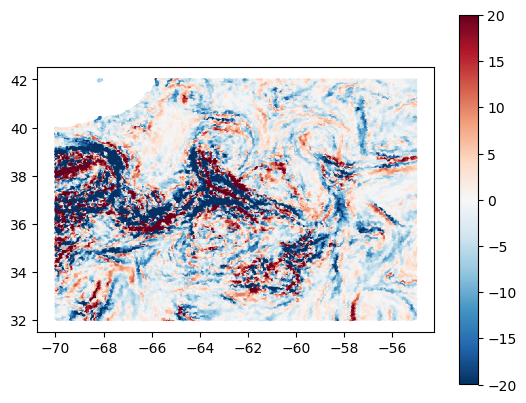

<xarray.DataArray (nz1: 40)> Size: 320B
dask.array<truediv, shape=(40,), dtype=float64, chunksize=(4,), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    Mixed Layer Depth
    units:        m
    description:  Mixed Layer Depth
    datapath:     /work/uo0119/a270067/runtime/awicm3-v3.1/N50/outdata/fesom/...
    runid:        fesom
    do_file:      run
    ...           ...
    str_ldep:     
    str_lsave:    MLD2.fesom.2094.nc_mJan.
    is_data:      scalar
    is_ie2n:      False
    do_compute:   False
    descript:      <xarray.DataArray 'mul-c05b270ae232b24bb2ad29b856b7aaa9' (nz1: 40, nod2: 65150)> Size: 21MB
dask.array<where, shape=(40, 65150), dtype=float64, chunksize=(4, 9991), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
  * nod2     (nod2) int64 521kB 6218361 6218370 6218371 ... 6508615 6508616 <xarra

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

3


...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

9


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 377.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 381.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask direc

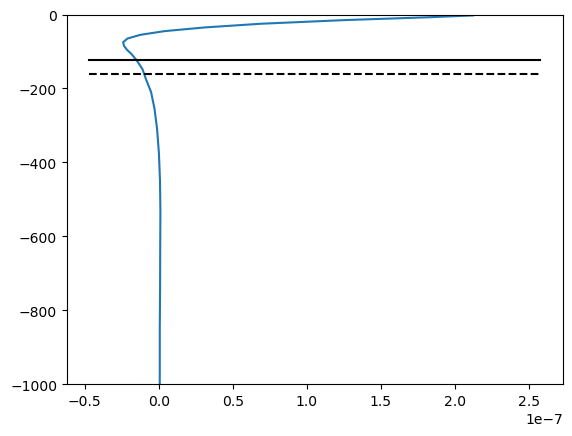

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 386.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-pr

2094


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

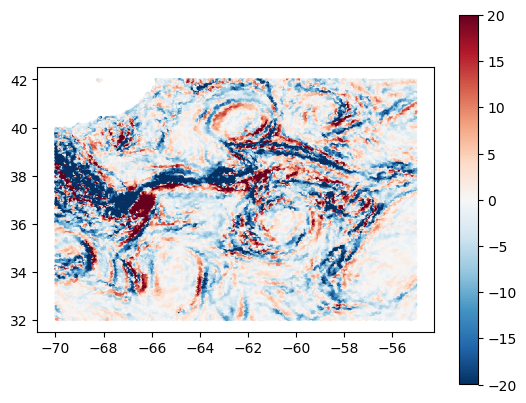

<xarray.DataArray (nz1: 40)> Size: 320B
dask.array<truediv, shape=(40,), dtype=float64, chunksize=(4,), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    Mixed Layer Depth
    units:        m
    description:  Mixed Layer Depth
    datapath:     /work/uo0119/a270067/runtime/awicm3-v3.1/N50/outdata/fesom/...
    runid:        fesom
    do_file:      run
    ...           ...
    str_ldep:     
    str_lsave:    MLD2.fesom.2095.nc_mJan.
    is_data:      scalar
    is_ie2n:      False
    do_compute:   False
    descript:      <xarray.DataArray 'mul-c05b270ae232b24bb2ad29b856b7aaa9' (nz1: 40, nod2: 65150)> Size: 21MB
dask.array<where, shape=(40, 65150), dtype=float64, chunksize=(4, 9991), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
  * nod2     (nod2) int64 521kB 6218361 6218370 6218371 ... 6508615 6508616 <xarra

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

3


...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

9


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 377.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 381.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask direc

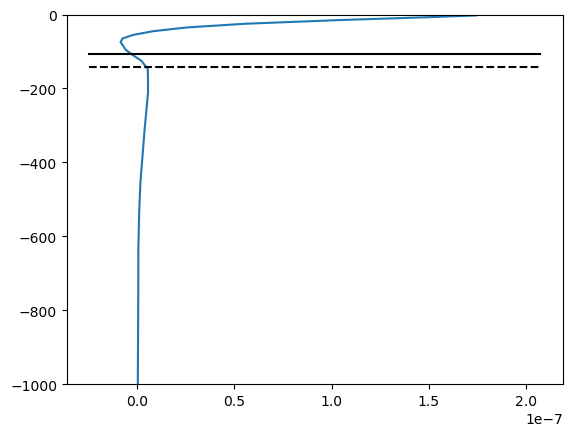

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 386.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-pr

2095


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

In [ ]:
ystart = 2091

JFM = np.arange(1,4, dtype=int)
JFMJAS = np.concatenate((JFM,
                         np.arange(7,10, dtype=int)))

reg = "GulfStrEx"

for yy in range(ystart,2101):
    
    h3_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                      % (NXX,yy))
    h2_path = op.join(ddir,'N%02d/outdata/fesom/MLD2.fesom.%4d.nc'
                      % (NXX,yy))
    
    maskS = xr.open_zarr(op.join(sdir,"fesom2/next/salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
        
    months = JFMJAS
    
    for mm in months:
        mld2 = tpv.load_data_fesom2(mesh, h2_path, do_filename=True,
                                  vname="MLD2", do_info=False,
                                  year=yy, mon=[mm]
                                 )
        m2gs = mld2.MLD2
        m2gs.coords["nod2"] = ("nod2",np.arange(len(mld2.nod2)))
        m2gs = m2gs.where((m2gs < 0.) 
                          & (depth.load() < -2e2),
                          drop=True
                         )
        m2gs = m2gs.where((m2gs.lat>regions[reg]["so"]) 
                          & (m2gs.lat<regions[reg]["no"])
                          & (m2gs.lon>regions[reg]["we"]) 
                          & (m2gs.lon<regions[reg]["ea"]),
                          drop=True
                         )
        mld3 = tpv.load_data_fesom2(mesh, h3_path, do_filename=True,
                                  vname="MLD3", do_info=False,
                                  year=yy, mon=[mm]
                                 )
        m3gs = mld3.MLD3
        m3gs.coords["nod2"] = ("nod2",np.arange(len(mld3.nod2)))
        m3gs = m3gs.where((m3gs < 0.) 
                          & (depth < -2e2),
                          drop=True
                         )
        m3gs = m3gs.where((m3gs.lat>regions[reg]["so"]) 
                          & (m3gs.lat<regions[reg]["no"])
                          & (m3gs.lon>regions[reg]["we"]) 
                          & (m3gs.lon<regions[reg]["ea"]),
                          drop=True
                         )
        
        dspw = xr.open_zarr(op.join(sdir,
                                    "fesom2/next/ppdwp/ppdwp_%4d-%02d.zarr" 
                                    % (yy,mm))
                           )
        
        ppdwp = dspw.WpRHOp
        ppdwp.coords["nod2"] = ("nod2",np.arange(len(mld2.nod2)))
        area.coords["nod2"] = ("nod2",np.arange(len(mld2.nod2)))
        ppdwp.coords["lon"] = mld2.lon
        ppdwp.coords["lat"] = mld2.lat
        area.coords["lon"] = mld2.lon
        area.coords["lat"] = mld2.lat
        if mm == 1:
            mask_gs = maskS.isel(time=mm-1).reset_coords(drop=True).load()
            ppdwp_gs = (ppdwp*area.reset_coords(drop=True)
                       ).where((~mask_gs) & (depth < -2e2),
                               drop=True
                              )
            ppdwp_gs = ppdwp_gs.where((ppdwp_gs.lat>regions[reg]["so"]) 
                                      & (ppdwp_gs.lat<regions[reg]["no"])
                                      & (ppdwp_gs.lon>regions[reg]["we"]) 
                                      & (ppdwp_gs.lon<regions[reg]["ea"]),
                                      drop=True
                                     )
            fig, ax = plt.subplots()
            im = ax.scatter(ppdwp_gs.lon, ppdwp_gs.lat, c=ppdwp_gs.isel(nz1=1),
                       s=1, cmap="RdBu_r", vmin=-2e1, vmax=2e1,
                       rasterized=True)
            ax.set_aspect("equal")
            fig.colorbar(im)
            plt.show()
            area_gs = area.where((~mask_gs) & (depth < -2e2),
                                 drop=True
                                )
            area_gs = area_gs.where((area_gs.lat>regions[reg]["so"]) 
                                    & (area_gs.lat<regions[reg]["no"])
                                    & (area_gs.lon>regions[reg]["we"]) 
                                    & (area_gs.lon<regions[reg]["ea"]),
                                    drop=True
                                   ).reset_coords(drop=True)
            ppdwp_gs = (ppdwp_gs.sum("nod2",skipna=True)
                        / area_gs.sum("nod2",skipna=True)
                       )
            mld2_gs = ((m2gs*area_gs).sum("nod2",skipna=True)
                       / area_gs.sum("nod2",skipna=True))
            mld3_gs = ((m3gs*area_gs).sum("nod2",skipna=True)
                       / area_gs.sum("nod2",skipna=True))
            print(mld2_gs, area_gs, ppdwp_gs)
        else:
            tmp_gs = (ppdwp*area.reset_coords(drop=True)
                     ).where((~mask_gs) & (depth < -2e2),
                             drop=True
                            )
            tmp_gs = tmp_gs.where((tmp_gs.lat>regions[reg]["so"]) 
                                  & (tmp_gs.lat<regions[reg]["no"])
                                  & (tmp_gs.lon>regions[reg]["we"]) 
                                  & (tmp_gs.lon<regions[reg]["ea"]),
                                  drop=True
                                 )
            # area_gs = area.where((~maskS.isel(time=mm-1).reset_coords(drop=True))
            #                      & (diag.zbar_n_bottom < -2e2),
            #                      drop=True
            #                     )
            # area_gs = area_gs.where((area.lat>31) & (area.lat<45)
            #                         & (area.lon>-80) & (area.lon<-60),
            #                         drop=True
            #                        ).reset_coords(drop=True)
            tmp_gs = (tmp_gs.sum("nod2",skipna=True)
                      / area_gs.sum("nod2",skipna=True)
                     )
            ppdwp_gs = xr.concat([ppdwp_gs, tmp_gs
                                 ], "time")
            mld2_gs = xr.concat([mld2_gs, 
                                 ((m2gs*area_gs).sum("nod2",skipna=True)
                                  / area_gs.sum("nod2",skipna=True))
                                ], "time")
            mld3_gs = xr.concat([mld3_gs, 
                                 ((m3gs*area_gs).sum("nod2",skipna=True)
                                  / area_gs.sum("nod2",skipna=True))
                                ], "time")
            del tmp_gs
        print(mm)
    
    ppdwp_gs.coords["time"] = ("time",JFMJAS)
    mld2_gs.coords["time"] = ("time",JFMJAS)
    mld3_gs.coords["time"] = ("time",JFMJAS)
    
    fig, ax = plt.subplots()
    ax.plot(-ppdwp_gs.isel(time=slice(None,3)).mean(["time"]), 
            -ppdwp_gs.nz1)
    ax.plot(np.linspace((-ppdwp_gs).min(skipna=True).data,
                        (-ppdwp_gs).max(skipna=True).data, 5),
            np.ones(5)*mld2_gs.isel(time=slice(None,3)).mean().data, "k--"
           )
    ax.plot(np.linspace((-ppdwp_gs).min(skipna=True).data,
                        (-ppdwp_gs).max(skipna=True).data, 5),
            np.ones(5)*mld3_gs.isel(time=slice(None,3)).mean().data, "k"
           )
    # ax.set_xlim([ppdwp_gs.min(skipna=True).data,
    #              ppdwp_gs.max(skipna=True).data])
    ax.set_ylim([-1e3,0])
    plt.show()
    
    dsave = ppdwp_gs.to_dataset(name="WpRHOp")
    dsave["MLD2"] = mld2_gs
    dsave["MLD3"] = mld3_gs
    dsave.reset_coords(drop=True).to_zarr(wdir+"ppdwp/N%2d/" % NXX +reg+"_%4d.zarr" % yy,
                                          mode="w")
    print(yy)